# E13 — LLM-as-a-Judge Disagreement

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Read a **judge log** — the table a model-graded evaluation actually produces — and turn it into verdicts
- Measure the three things that decide whether a judge score means anything: **position bias**,
  **self-inconsistency**, and **inter-judge agreement** (Cohen's κ)
- See why **raw agreement flatters a judge and κ does not**, on numbers you compute yourself
- Run the protocol experiment that matters: report a win rate the usual way, then change **one thing**
  about the protocol, re-run, and compare both answers against a value you actually know
- Say precisely what a judge-based number does and does not license you to claim

## 🔗 Where this fits

**Builds on:** Unit 4 lesson 05 [`examples/05_hitl_approaches.ipynb`](../examples/05_hitl_approaches.ipynb) —
you built confidence-based routing there: the model decides what it is sure about and **defers the rest to
a human**. This notebook is about the move everyone makes next, when the human queue gets too long: replace
the human with a second model. It also builds on lesson 04 (`04_accountability_frameworks.ipynb`) — a judge
score is a decision about someone's work, so it belongs in an audit trail like any other decision, and
somebody has to be accountable for it.

**Used later in:** Course 12 (AIAT 126) Unit 4, `01_model_evaluation_optimization.ipynb`, is where your own
capstone's evaluation numbers get reported. The protocol argument below is the one to have *before* you
write that section, and it applies to any output a metric cannot score — a summary, a translation, an
explanation, a piece of generated code.

## 🌍 Why this matters: the grader became a model

Open-ended output — a summary, an explanation, an Arabic translation, a piece of code — has no answer key.
For a decade the workaround was a proxy metric (BLEU, ROUGE) that nobody believed. Since 2023 the workaround
is **a second language model asked "which of these two responses is better?"**, and it is now how most
systems in industry are graded, ranked, and compared in a slide deck.

## 📌 The case: MT-Bench and Chatbot Arena, where the practice was named *and* its biases published

Zheng et al. (2023) introduced **MT-Bench** and **Chatbot Arena** and, in the same paper, wrote down what is
wrong with the method they were proposing. Their abstract names four failure modes: **position bias**,
**verbosity bias**, **self-enhancement bias**, and limited reasoning ability. Their headline result is the
reason everyone adopted it anyway: strong judges "can match both controlled and crowdsourced human
preferences well, achieving over 80% agreement, the same level of agreement between humans"
([arXiv:2306.05685](https://arxiv.org/abs/2306.05685)). The paper released 3K expert votes and 30K
conversations so the claim could be checked.

Two years later the picture is more specific and less comfortable. **TrustJudge** (Wang et al., 2025) names
two inconsistencies and measures them: **score-comparison inconsistency**, where a response rated lower wins
the head-to-head, and **pairwise transitivity inconsistency** — circular preferences, A > B > C > A. Their
reported reductions tell you the baseline rates: score-comparison inconsistency fell **from 23.32% to
14.89%**, and transitivity inconsistency **from 15.22% to 4.40%**
([arXiv:2509.21117](https://arxiv.org/abs/2509.21117)).

Sit with the first of those numbers. Roughly **one judgement in four** contradicted the same judge's own
scores of the same two responses, before mitigation.

**What goes wrong without this lesson.** A team reports "our new model wins 78% of head-to-heads against the
old one" from a single judge, in a single presentation order, on one pass. Every one of those three
decisions moves the number, and none of them appears in the slide. Lee et al. (2025) set out what a correct
report requires instead: a human-labelled calibration set, a bias correction, and confidence intervals that
account for uncertainty in **both** the test set and the calibration set
([arXiv:2511.21140](https://arxiv.org/abs/2511.21140)).

## 📥 Inputs & 📤 Outputs

### ⚠️ Read this before you quote a single number below

The three CSV files this notebook loads are **bundled artifacts, not live model output**. Nothing here calls
a model, an API, or the network. The "judges" are a **simulator**: each one is three numbers — a bonus
applied to whichever response is shown first, a leniency offset, and a noise level — added to a latent
quality score and rounded to an integer 1–5. The generator is checked in beside this notebook as
[`make_judge_log.py`](make_judge_log.py); read it. **No number produced from these files is evidence about
any real model, vendor, or judge configuration.** For measured magnitudes from real judges, use the papers
cited above.

That is not a compromise — it is why the lesson works. With a real judge log you can *compute* a position
bias but you can never *check* it, because nobody knows the true value. Here the true value is written down
in `generator_parameters.csv`, so this notebook can ask the only question that really matters about an
evaluation protocol: **does it recover an answer we already know?** A protocol that fails that test on
simulated data has no business being used on real data.

**Inputs (all in this folder, all offline):**

- `judge_log.csv` — 1,440 rows: 120 items × 3 judges × 2 presentation orders × 2 passes
- `items.csv` — 120 response pairs with their latent quality, the **true preference**, and one human label
- `generator_parameters.csv` — the true per-judge simulator settings, used only at the very end

**Outputs:** verdicts derived from raw scores; a baseline win rate with a Wilson interval; per-judge position
preference and order consistency; self-inconsistency across two passes; a raw-agreement vs Cohen's κ matrix;
a two-protocol comparison against the known truth; and a two-panel chart.

## Part 1: What a Judge Log Actually Looks Like

A judge log is boring, and that is the point: one row per judgement, with the **conditions of the judgement**
recorded alongside the scores. Most published evaluations never show you this table — they show you the
average of one column of it.

Three fields here are the ones teams forget to record, and every one of them turns out to matter:

- `presentation_order` — `AB` means response R1 was shown first, `BA` means R2 was
- `pass` — the same judge asked the identical question a second time
- `judge` — which judge configuration produced the row

If your evaluation harness does not log those three, none of the diagnostics below can be computed after
the fact. That is the practical takeaway of this whole notebook, and you can act on it before you ever
call a judge.

In [1]:
# WHAT: load the three bundled CSVs and print exactly what is in them.
# WHY:  the shape of an evaluation table tells you which questions it can answer. 2 orders x 2 passes is
#       what makes position bias and self-inconsistency measurable at all - most real logs have neither.
from pathlib import Path
import urllib.parse, urllib.request
import numpy as np
import pandas as pd

# WHAT: find the folder holding this notebook's three bundled CSVs, wherever the kernel started.
# WHY:  Path.cwd() is this folder ONLY when the kernel happens to start here. Open the notebook
#       from the repository root, from JupyterLab at another level, or on Google Colab where
#       there is no repository at all, and a cwd-relative path silently points at nothing.
BUNDLED = ["judge_log.csv", "items.csv", "generator_parameters.csv"]
REL = "Course 06/unit4-transparency-accountability/enrichment"

_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
_candidates += [p / REL for p in _candidates]
HERE = next((p for p in _candidates if all((p / f).exists() for f in BUNDLED)), None)
if HERE is None:                      # Google Colab, or a stray copy of the notebook
    HERE = Path("E13_bundled_artifacts")
    HERE.mkdir(exist_ok=True)
    _base = "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
    for _f in BUNDLED:
        urllib.request.urlretrieve(_base + urllib.parse.quote(f"{REL}/{_f}"), HERE / _f)
    print("No repository here, so the three bundled CSVs were downloaded from GitHub.")
print(f"Bundled evaluation artifacts read from {HERE.name}/ - no hard-coded path was used.\n")

log = pd.read_csv(HERE / "judge_log.csv")
items = pd.read_csv(HERE / "items.csv")
true_params = pd.read_csv(HERE / "generator_parameters.csv")

print(f"judge_log.csv : {len(log):,} rows x {log.shape[1]} columns")
print(f"                {log['item_id'].nunique()} items"
      f" | judges {sorted(log['judge'].unique().tolist())}"
      f" | orders {sorted(log['presentation_order'].unique().tolist())}"
      f" | passes {sorted(int(p) for p in log['pass'].unique())}")
print(f"items.csv     : {len(items):,} rows x {items.shape[1]} columns\n")

print("First six rows of the judge log - one row is one judgement:\n")
print(log.head(6).to_string(index=False))
print("\nFirst three items - latent quality is what a real log NEVER contains:\n")
print(items.head(3).to_string(index=False))
print("\nREMINDER: these judges are a simulator (see make_judge_log.py). No model was queried.")

Bundled evaluation artifacts read from enrichment/ - no hard-coded path was used.

judge_log.csv : 1,440 rows x 6 columns
                120 items | judges ['judge_A', 'judge_B', 'judge_C'] | orders ['AB', 'BA'] | passes [1, 2]
items.csv     : 120 rows x 5 columns

First six rows of the judge log - one row is one judgement:

item_id   judge presentation_order  pass  score_first  score_second
   Q001 judge_A                 AB     1            4             3
   Q001 judge_A                 AB     2            4             3
   Q001 judge_A                 BA     1            4             4
   Q001 judge_A                 BA     2            4             4
   Q002 judge_A                 AB     1            4             3
   Q002 judge_A                 AB     2            4             3

First three items - latent quality is what a real log NEVER contains:

item_id  latent_quality_r1  latent_quality_r2 true_preference human_label
   Q001              3.466              2.936     

## Part 2: From Scores to Verdicts — Undoing the Shuffle

The judge was shown two responses in one of two orders and scored them "first" and "second". Before anything
can be compared across rows, those have to be mapped back onto the **responses themselves**: R1 and R2.

This unshuffling step is where evaluation harnesses quietly go wrong. If you record only *"the judge
preferred the first one"* and forget which response that was, the log is unrecoverable. If you swap the
mapping for one order, you invent a bias that is not there.

A verdict is then just a comparison: R1 wins, R2 wins, or a tie. Ties are not a nuisance to be dropped
silently — watch how many there are.

In [2]:
# WHAT: map (score_first, score_second) back onto (R1, R2) using the recorded order, then derive a verdict.
# WHY:  every later statistic is a function of `winner`. Getting this eight-line block wrong silently
#       corrupts the entire evaluation, and nothing downstream will complain.
shown_r1_first = log["presentation_order"] == "AB"          # 'AB' = R1 first, 'BA' = R2 first

log["score_r1"] = np.where(shown_r1_first, log["score_first"], log["score_second"])
log["score_r2"] = np.where(shown_r1_first, log["score_second"], log["score_first"])
log["winner"] = np.select([log["score_r1"] > log["score_r2"],
                           log["score_r2"] > log["score_r1"]], ["R1", "R2"], default="tie")

# Did the judge prefer whichever response happened to be shown first? (NaN where it called a tie.)
log["prefers_first"] = np.where(log["score_first"] > log["score_second"], 1.0,
                                np.where(log["score_second"] > log["score_first"], 0.0, np.nan))

verdicts = log["winner"].value_counts(normalize=True).reindex(["R1", "R2", "tie"])
print("Verdict distribution over all 1,440 judgements:")
for k, v in verdicts.items():
    print(f"  {k:>4}: {v:6.1%}")

# The value we are trying to estimate, and which a real evaluation never has access to.
decisive_items = items[items["true_preference"] != "tie"]
TRUE_R1_WIN_RATE = (decisive_items["true_preference"] == "R1").mean()
print(f"\nGround truth (from the simulator, not from any judge):")
print(f"  items where one response is genuinely better : {len(decisive_items)} of {len(items)}")
print(f"  true R1 win rate over those items            : {TRUE_R1_WIN_RATE:.1%}")
print(f"  the human annotator's labels match the truth : "
      f"{(items['human_label'] == items['true_preference']).mean():.1%} of the time")

Verdict distribution over all 1,440 judgements:
    R1:  45.9%
    R2:  23.7%
   tie:  30.4%

Ground truth (from the simulator, not from any judge):
  items where one response is genuinely better : 101 of 120
  true R1 win rate over those items            : 62.4%
  the human annotator's labels match the truth : 86.7% of the time


## Part 3: The Baseline Protocol — One Judge, One Order, One Pass

This is how a judge-based number is produced in the overwhelming majority of reports: pick a judge, show
each pair once in a fixed order, take one pass, count wins, quote the percentage.

We will compute it for `judge_A`, attach a **Wilson 95% interval** (the right interval for a proportion —
the textbook `p ± 1.96·√(p(1−p)/n)` misbehaves near 0 and 1), and then do the thing a real evaluation can
never do: compare it against the true value.

In [3]:
# WHAT: the standard single-judge, single-order, single-pass win rate, with a Wilson 95% interval.
# WHY:  the interval is the honest part. It answers "how much of this number is sampling noise?" - but
#       notice what it does NOT answer, which is the entire point of Part 4.
import math


def wilson(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    '''Wilson score interval for a binomial proportion - stable at small n and near 0 or 1.'''
    if n == 0:
        return (float("nan"), float("nan"))
    p = successes / n
    denom = 1 + z * z / n
    centre = p + z * z / (2 * n)
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return ((centre - half) / denom, (centre + half) / denom)


baseline = log[(log["judge"] == "judge_A") & (log["pass"] == 1) &
               (log["presentation_order"] == "AB")]
baseline_decisive = baseline[baseline["winner"] != "tie"]
wins = int((baseline_decisive["winner"] == "R1").sum())
n = len(baseline_decisive)
lo, hi = wilson(wins, n)

print("BASELINE PROTOCOL: judge_A, presentation order AB only, pass 1 only")
print(f"  decisive judgements      : {n} of {len(baseline)} ({len(baseline) - n} ties dropped)")
print(f"  R1 win rate              : {wins}/{n} = {wins / n:.1%}")
print(f"  Wilson 95% interval      : [{lo:.1%}, {hi:.1%}]")
print(f"  TRUE R1 win rate         : {TRUE_R1_WIN_RATE:.1%}")
print(f"  does the interval contain the truth? {'YES' if lo <= TRUE_R1_WIN_RATE <= hi else 'NO'}")
print("\nThe interval is correctly computed and the sample is not small. It still misses, because a")
print("confidence interval quantifies sampling noise and nothing else. Bias is not noise.")

BASELINE PROTOCOL: judge_A, presentation order AB only, pass 1 only
  decisive judgements      : 94 of 120 (26 ties dropped)
  R1 win rate              : 80/94 = 85.1%
  Wilson 95% interval      : [76.5%, 90.9%]
  TRUE R1 win rate         : 62.4%
  does the interval contain the truth? NO

The interval is correctly computed and the sample is not small. It still misses, because a
confidence interval quantifies sampling noise and nothing else. Bias is not noise.


## Part 4: Position Bias — the Judge Prefers Whatever Is on the Left

Position bias is the failure mode Zheng et al. listed first, and it is the one a single-order evaluation
cannot see at all. Two measurements make it visible, and they say different things:

- **Preference for the first-shown response.** Over both orders, how often did the judge pick whichever
  response was presented first? With no bias this is 50%, up to noise.
- **Order consistency.** Take the items where the judge gave a decisive verdict in *both* orders. How often
  was the verdict the same? This is the metric MT-Bench-style evaluations report as "consistency", and it is
  a per-item measure rather than an aggregate.

Then the check that only simulated data allows. `mean(score_first − score_second)` averaged over **both**
orders cancels the real quality difference and leaves the position effect behind — so it is an estimator of
the first-position bonus. We know the true bonus. Does the estimator find it?

In [4]:
# WHAT: measure position preference, order consistency, and estimate each judge's first-position bonus.
# WHY:  the third measurement is the one you cannot do at work. Doing it here is how you earn the right to
#       trust the first two, which you CAN do at work.
rows = []
for judge in sorted(log["judge"].unique()):
    sub = log[log["judge"] == judge]

    # 1. how often the first-shown response won, over decisive judgements in both orders
    dec = sub[sub["winner"] != "tie"]
    first_won = int(dec["prefers_first"].sum())
    p_first, ci = first_won / len(dec), wilson(first_won, len(dec))

    # 2. order consistency: same item, same pass, both orders decisive - did the verdict survive the swap?
    p1 = sub[sub["pass"] == 1]
    ab = p1[p1["presentation_order"] == "AB"].set_index("item_id")["winner"]
    ba = p1[p1["presentation_order"] == "BA"].set_index("item_id")["winner"]
    both_decisive = (ab != "tie") & (ba != "tie")
    consistency = (ab[both_decisive] == ba[both_decisive]).mean()

    # 3. the estimator: averaged over both orders, the true quality gap cancels and the bonus remains
    bonus_hat = (sub["score_first"] - sub["score_second"]).mean()
    bonus_true = float(true_params.loc[true_params["judge"] == judge, "first_position_bonus"].iloc[0])

    rows.append({"judge": judge, "n_decisive": len(dec), "prefers_first": p_first,
                 "ci_low": ci[0], "ci_high": ci[1], "order_consistency": consistency,
                 "n_both_decisive": int(both_decisive.sum()),
                 "bonus_estimated": bonus_hat, "bonus_true": bonus_true})

bias_df = pd.DataFrame(rows)
print("POSITION BIAS\n")
for r in bias_df.itertuples():
    verdict = "no detectable bias" if r.ci_low <= 0.5 <= r.ci_high else "BIASED (0.5 outside the interval)"
    print(f"{r.judge}")
    print(f"  prefers the first-shown response : {r.prefers_first:.1%}  "
          f"95% CI [{r.ci_low:.1%}, {r.ci_high:.1%}]  n={r.n_decisive}   -> {verdict}")
    print(f"  order consistency (both orders decisive, n={r.n_both_decisive}) : {r.order_consistency:.1%}")
    print(f"  first-position bonus: estimated {r.bonus_estimated:+.3f} vs TRUE {r.bonus_true:+.3f} "
          f"(error {r.bonus_estimated - r.bonus_true:+.3f})")
    print()
print("The estimator lands close to the true bonus for all three judges - so the same estimator,")
print("applied to a real judge log with both orders recorded, is worth computing.")

POSITION BIAS

judge_A
  prefers the first-shown response : 71.2%  95% CI [66.2%, 75.8%]  n=344   -> BIASED (0.5 outside the interval)
  order consistency (both orders decisive, n=61) : 82.0%
  first-position bonus: estimated +0.535 vs TRUE +0.500 (error +0.035)

judge_B
  prefers the first-shown response : 53.8%  95% CI [48.5%, 59.1%]  n=338   -> no detectable bias
  order consistency (both orders decisive, n=61) : 95.1%
  first-position bonus: estimated +0.090 vs TRUE +0.080 (error +0.010)

judge_C
  prefers the first-shown response : 63.1%  95% CI [57.7%, 68.2%]  n=320   -> BIASED (0.5 outside the interval)
  order consistency (both orders decisive, n=60) : 96.7%
  first-position bonus: estimated +0.258 vs TRUE +0.300 (error -0.042)

The estimator lands close to the true bonus for all three judges - so the same estimator,
applied to a real judge log with both orders recorded, is worth computing.


## Part 5: Self-Inconsistency — the Same Judge, the Same Question, a Different Answer

Ask the judge the identical question a second time, with the response order held fixed. Any change is not
bias and not a difference of opinion — it is the judge disagreeing with itself, and it puts a hard ceiling
on agreement with anything else.

This is the practical face of the inconsistency TrustJudge measures. It is also trivially cheap to detect
and almost never reported: it costs one extra pass over your evaluation set.

In [5]:
# WHAT: compare pass 1 against pass 2 for identical (item, judge, presentation order) triples.
# WHY:  a judge that cannot reproduce its own verdict cannot agree with a human more often than it agrees
#       with itself. This number is the ceiling on every agreement statistic that follows.
key = ["item_id", "presentation_order"]
consistency_rows = []
for judge in sorted(log["judge"].unique()):
    sub = log[log["judge"] == judge]
    a = sub[sub["pass"] == 1].sort_values(key).reset_index(drop=True)
    b = sub[sub["pass"] == 2].sort_values(key).reset_index(drop=True)
    assert (a["item_id"].values == b["item_id"].values).all()      # the two passes must line up exactly
    consistency_rows.append({
        "judge": judge,
        "verdict_changed": (a["winner"] != b["winner"]).mean(),
        "mean_abs_score_change": (a["score_first"] - b["score_first"]).abs().mean(),
        "identical_scores": ((a["score_first"] == b["score_first"]) &
                             (a["score_second"] == b["score_second"])).mean(),
    })

self_df = pd.DataFrame(consistency_rows)
print("SELF-INCONSISTENCY: same judge, same item, same order, asked twice\n")
print(self_df.rename(columns={
    "verdict_changed": "verdict flipped",
    "mean_abs_score_change": "mean |score change|",
    "identical_scores": "both scores identical"}).to_string(index=False,
    formatters={"verdict flipped": "{:.1%}".format,
                "mean |score change|": "{:.3f}".format,
                "both scores identical": "{:.1%}".format}))
print("\njudge_B is the interesting one: barely any position bias (Part 4) and the worst self-agreement.")
print("Bias and noise are different defects and they need different fixes - averaging fixes only one.")

SELF-INCONSISTENCY: same judge, same item, same order, asked twice

  judge verdict flipped mean |score change| both scores identical
judge_A           13.3%               0.104                 75.0%
judge_B           37.1%               0.362                 39.2%
judge_C           10.8%               0.083                 80.0%

judge_B is the interesting one: barely any position bias (Part 4) and the worst self-agreement.
Bias and noise are different defects and they need different fixes - averaging fixes only one.


## Part 6: Do the Judges Agree With Each Other? Raw Agreement vs Cohen's κ

The reflex check on a judge is "how often do two judges agree?" That number is almost always reassuring,
and almost always misleading, because two judges who both say "R1" most of the time will agree often **by
accident**.

**Cohen's κ** (Cohen, 1960) removes exactly that accident:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

where $p_o$ is observed agreement and $p_e$ is the agreement expected from each rater's own marginal rates.
κ = 1 is perfect, κ = 0 is chance-level, and κ can be negative.

The conventional labels — 0.41–0.60 "moderate", 0.61–0.80 "substantial" — come from Landis & Koch (1977).
They are a **convention with no theoretical basis**, published for a specific clinical setting. Quote the
number; treat the adjective as a rough hint.

In [6]:
# WHAT: raw pairwise agreement next to Cohen's kappa, on the baseline slice (AB order, pass 1).
# WHY:  printing them side by side is the shortest possible demonstration of why raw agreement is not
#       evidence. The gap between the two columns is pure chance agreement.
from sklearn.metrics import cohen_kappa_score

pivot = (log[(log["pass"] == 1) & (log["presentation_order"] == "AB")]
         .pivot(index="item_id", columns="judge", values="winner"))

pairs = [("judge_A", "judge_B"), ("judge_A", "judge_C"), ("judge_B", "judge_C")]
agree_rows = [{"pair": f"{x} vs {y}",
               "raw_agreement": (pivot[x] == pivot[y]).mean(),
               "cohens_kappa": cohen_kappa_score(pivot[x], pivot[y])} for x, y in pairs]
agree_df = pd.DataFrame(agree_rows)

print("INTER-JUDGE AGREEMENT (order AB, pass 1, 120 items)\n")
print(agree_df.to_string(index=False, formatters={"raw_agreement": "{:.1%}".format,
                                                  "cohens_kappa": "{:.3f}".format}))

print("\nWhere the gap comes from - each judge's own marginal rates:\n")
print(pivot.apply(lambda c: c.value_counts(normalize=True)).fillna(0)
      .to_string(float_format=lambda v: f"{v:.1%}"))
print("\nAll three judges say R1 more often than anything else, so a share of every agreement above")
print("is coincidence. kappa charges them for it; raw agreement does not.")

INTER-JUDGE AGREEMENT (order AB, pass 1, 120 items)

              pair raw_agreement cohens_kappa
judge_A vs judge_B         60.8%        0.354
judge_A vs judge_C         75.8%        0.563
judge_B vs judge_C         67.5%        0.477

Where the gap comes from - each judge's own marginal rates:

judge  judge_A  judge_B  judge_C
R1       66.7%    44.2%    54.2%
tie      21.7%    34.2%    32.5%
R2       11.7%    21.7%    13.3%

All three judges say R1 more often than anything else, so a share of every agreement above
is coincidence. kappa charges them for it; raw agreement does not.


## 💬 Discuss

1. **Which judge would you deploy?** `judge_A` has by far the clearest position bias and reproduces its own
   verdicts most of the time; `judge_B` has no position bias the interval can detect and flips its own
   verdict on more than a third of repeated judgements. You must pick one to grade a certification exam.
   Which defect would you rather explain to the candidate who failed — and does your answer change if you
   are allowed to run every item in both orders, twice?
2. **What is the honest headline?** Part 3 produced a win rate with a correctly computed 95% interval that
   does not contain the true value. If a colleague publishes that number with that interval, they have done
   nothing statistically wrong. What exactly is missing from their report, and where in a model card or an
   evaluation card would you put it?
3. **Ties.** Roughly a third of all judgements here are ties, and Part 3 simply dropped them before
   computing a percentage. Argue for a different treatment — count ties as half a win, report them as their
   own category, or force the judge to choose. What does each choice do to a comparison between two systems
   that are genuinely very close?

## Part 7: The Experiment — Change the Protocol, Keep Everything Else

Baseline: one judge, one order (`AB`), one pass, aggregated over **judgements**.

Change exactly one thing — **the protocol**, not the judge, not the data, not the items:

> Use **both** presentation orders and **both** passes, aggregate the four judgements **per item** by
> majority (ties among the votes stay ties), then compute the win rate over items.

Every score in the table was already collected. Nothing new is measured. If the answer moves, the movement
was always an artifact of how the existing numbers were read.

Two things get recomputed: the **R1 win rate** against the known truth, and **agreement with the human
labels** in `items.csv` — the calibration set Lee et al. argue every judge-based report needs
([arXiv:2511.21140](https://arxiv.org/abs/2511.21140)).

In [7]:
# WHAT: recompute the same win rate under an order-balanced, two-pass, per-item protocol, and re-measure
#       agreement with the human labels under both protocols.
# WHY:  this is the whole lesson in one table. Same judges, same items, same scores - only the reading
#       changes, and the answer moves by more than the confidence interval ever admitted was possible.
def majority_vote(verdicts: pd.Series) -> str:
    '''Majority over the four judgements for one item. Tie votes abstain; an even split stays a tie.'''
    r1, r2 = (verdicts == "R1").sum(), (verdicts == "R2").sum()
    return "R1" if r1 > r2 else ("R2" if r2 > r1 else "tie")


per_item = log.groupby(["judge", "item_id"])["winner"].apply(majority_vote).unstack(0)
human = items.set_index("item_id")["human_label"].loc[per_item.index]

results = []
for judge in sorted(log["judge"].unique()):
    # --- protocol 1: the baseline ---
    b = log[(log["judge"] == judge) & (log["pass"] == 1) & (log["presentation_order"] == "AB")]
    bd = b[b["winner"] != "tie"]
    k1, n1 = int((bd["winner"] == "R1").sum()), len(bd)
    lo1, hi1 = wilson(k1, n1)

    # --- protocol 2: order-balanced, two passes, aggregated per item ---
    agg = per_item[judge]
    ad = agg[agg != "tie"]
    k2, n2 = int((ad == "R1").sum()), len(ad)
    lo2, hi2 = wilson(k2, n2)

    results.append({
        "judge": judge,
        "baseline_rate": k1 / n1, "baseline_n": n1, "baseline_err": k1 / n1 - TRUE_R1_WIN_RATE,
        "balanced_rate": k2 / n2, "balanced_n": n2, "balanced_err": k2 / n2 - TRUE_R1_WIN_RATE,
        "baseline_lo": lo1, "baseline_hi": hi1, "balanced_lo": lo2, "balanced_hi": hi2,
        "kappa_vs_human_baseline": cohen_kappa_score(pivot[judge], human),
        "kappa_vs_human_balanced": cohen_kappa_score(agg, human),
    })

res = pd.DataFrame(results)
print(f"TRUE R1 win rate = {TRUE_R1_WIN_RATE:.1%}   (known only because the judges are a simulator)\n")
print("R1 WIN RATE UNDER TWO PROTOCOLS\n")
for r in res.itertuples():
    print(f"{r.judge}")
    print(f"  baseline  (AB, pass 1, per judgement) : {r.baseline_rate:6.1%}  "
          f"[{r.baseline_lo:.1%}, {r.baseline_hi:.1%}]  n={r.baseline_n:3d}   error {r.baseline_err:+.1%}")
    print(f"  balanced  (both orders, both passes)  : {r.balanced_rate:6.1%}  "
          f"[{r.balanced_lo:.1%}, {r.balanced_hi:.1%}]  n={r.balanced_n:3d}   error {r.balanced_err:+.1%}")
    print(f"  agreement with the human labels (Cohen's kappa): "
          f"{r.kappa_vs_human_baseline:.3f}  ->  {r.kappa_vs_human_balanced:.3f}")
    print()

print(f"Mean absolute error against the truth:  baseline {res['baseline_err'].abs().mean():.1%}  ->  "
      f"balanced {res['balanced_err'].abs().mean():.1%}")
print(f"Mean Cohen's kappa against the humans:  baseline {res['kappa_vs_human_baseline'].mean():.3f}  ->  "
      f"balanced {res['kappa_vs_human_balanced'].mean():.3f}")

TRUE R1 win rate = 62.4%   (known only because the judges are a simulator)

R1 WIN RATE UNDER TWO PROTOCOLS

judge_A
  baseline  (AB, pass 1, per judgement) :  85.1%  [76.5%, 90.9%]  n= 94   error +22.7%
  balanced  (both orders, both passes)  :  67.3%  [57.9%, 75.4%]  n=107   error +4.9%
  agreement with the human labels (Cohen's kappa): 0.302  ->  0.545

judge_B
  baseline  (AB, pass 1, per judgement) :  67.1%  [56.1%, 76.4%]  n= 79   error +4.7%
  balanced  (both orders, both passes)  :  60.0%  [50.7%, 68.7%]  n=110   error -2.4%
  agreement with the human labels (Cohen's kappa): 0.426  ->  0.561

judge_C
  baseline  (AB, pass 1, per judgement) :  80.2%  [70.3%, 87.5%]  n= 81   error +17.9%
  balanced  (both orders, both passes)  :  63.1%  [53.5%, 71.8%]  n=103   error +0.7%
  agreement with the human labels (Cohen's kappa): 0.410  ->  0.514

Mean absolute error against the truth:  baseline 15.1%  ->  balanced 2.7%
Mean Cohen's kappa against the humans:  baseline 0.379  ->  balanced

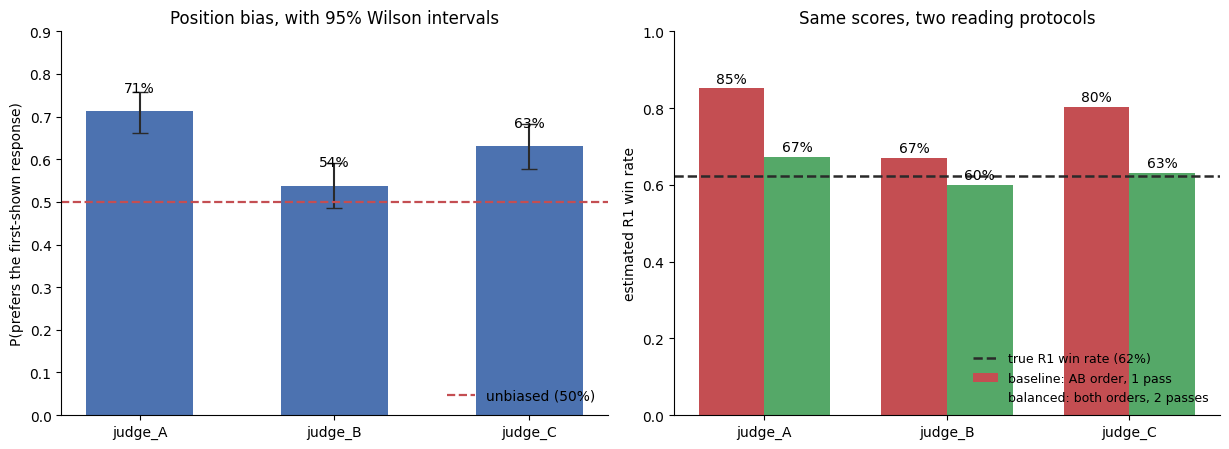

120 items is a small evaluation set: each item is worth roughly one percentage point on the
right-hand bars, and the intervals printed above are the honest width of these estimates.


In [8]:
# WHAT: the two findings as one figure - position preference per judge, and protocol error against truth.
# WHY:  the left panel is the diagnostic you can run on a real judge log; the right panel is the payoff.
%matplotlib inline
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.6))

# --- left: does the judge prefer whatever is shown first? 50% is the unbiased line. ---
xs = np.arange(len(bias_df))
err = np.vstack([bias_df["prefers_first"] - bias_df["ci_low"],
                 bias_df["ci_high"] - bias_df["prefers_first"]])
ax1.bar(xs, bias_df["prefers_first"], 0.55, color="#4C72B0", yerr=err, capsize=6, ecolor="#2a2a2a")
ax1.axhline(0.5, color="#C44E52", ls="--", lw=1.6, label="unbiased (50%)")
for x, v in zip(xs, bias_df["prefers_first"]):
    ax1.text(x, v + 0.045, f"{v:.0%}", ha="center", fontsize=10)
ax1.set_xticks(xs, bias_df["judge"])
ax1.set_ylim(0, 0.9)
ax1.set_ylabel("P(prefers the first-shown response)")
ax1.set_title("Position bias, with 95% Wilson intervals")
ax1.legend(frameon=False, loc="lower right")

# --- right: the same win rate read two ways, against the value we know. ---
w = 0.36
ax2.bar(xs - w / 2, res["baseline_rate"], w, label="baseline: AB order, 1 pass", color="#C44E52")
ax2.bar(xs + w / 2, res["balanced_rate"], w, label="balanced: both orders, 2 passes", color="#55A868")
ax2.axhline(TRUE_R1_WIN_RATE, color="#2a2a2a", ls="--", lw=1.8,
            label=f"true R1 win rate ({TRUE_R1_WIN_RATE:.0%})")
for x, (a, b) in enumerate(zip(res["baseline_rate"], res["balanced_rate"])):
    ax2.text(x - w / 2, a + 0.015, f"{a:.0%}", ha="center", fontsize=10)
    ax2.text(x + w / 2, b + 0.015, f"{b:.0%}", ha="center", fontsize=10)
ax2.set_xticks(xs, res["judge"])
ax2.set_ylim(0, 1.0)
ax2.set_ylabel("estimated R1 win rate")
ax2.set_title("Same scores, two reading protocols")
ax2.legend(frameon=False, loc="lower right", fontsize=9)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("120 items is a small evaluation set: each item is worth roughly one percentage point on the")
print("right-hand bars, and the intervals printed above are the honest width of these estimates.")

## ✅ Summary

**What you did here** (every number computed live above from the bundled log):

- Turned 1,440 raw judgements into verdicts, and found that about a third of them were **ties**
- Produced the standard headline number — one judge, one order, one pass — with a correctly computed
  Wilson 95% interval, and watched that interval **miss the true value entirely**
- Measured position bias two ways and recovered each judge's hidden first-position bonus to within a few
  hundredths, which is what licenses using the same estimator on a real log
- Measured self-inconsistency and found the judge with the *least* position bias had the *worst*
  self-agreement — bias and noise are separate defects
- Put raw agreement next to Cohen's κ and saw the gap that chance agreement accounts for
- Changed **one thing** — the reading protocol, not the data — and cut the mean absolute error against the
  truth while raising mean agreement with the human labels

**The one sentence to keep:** a judge-based win rate is a statement about a *protocol* as much as about a
model, and a confidence interval prices the sampling noise while saying nothing at all about the bias — so
report the protocol, or the number cannot be checked by anyone.

**What to do on Monday.** Log `presentation_order`, `pass` and `judge` on every judgement. Run both orders.
Keep a small human-labelled calibration set. None of that requires a bigger budget; it requires deciding
before you start.

## ⚠️ Where this breaks

**The judges are simulated, and the magnitudes are invented.** Say it out loud one more time: the position
bonuses, leniency offsets and noise levels in `make_judge_log.py` were chosen by hand to make three failure
modes visible in 120 items. They are **not calibrated to any published measurement**, and no percentage in
this notebook is evidence about any real judge. What transfers is the *procedure* — the estimators, the
intervals, the protocol comparison — not the values.

**A simulator cannot exhibit the failures nobody has parameterised.** Real judges also show verbosity bias
(longer answers score higher), self-enhancement bias (a model prefers its own outputs), sensitivity to the
rubric's wording, and drift when the vendor updates the model underneath you. None of those exist in this
file, so nothing here bounds them.

**Order balancing is a partial fix, not a correction.** The balanced estimates above are much closer to the
truth and still not equal to it. Averaging over presentation orders removes the *position* effect; it does
nothing about a judge that systematically rewards the wrong property in both orders. If the bias is in the
rubric rather than the layout, every protocol in this notebook will reproduce it faithfully.

**Cohen's κ has its own well-known pathology.** With very skewed marginals — say a judge that answers "R1"
90% of the time — κ can be low even when raw agreement is very high, and the two statistics then tell
genuinely different stories. Report both, and report the marginals, as we did in Part 6.

**Our human labels are one annotator with a fixed error rate.** Real calibration sets have several
annotators who disagree with each other, and that disagreement is itself the ceiling on what any judge can
score. Lee et al.'s framework exists precisely because the calibration set carries uncertainty that has to
be propagated into the final interval ([arXiv:2511.21140](https://arxiv.org/abs/2511.21140)).

**Two passes measure repeatability, not reliability.** A judge could be perfectly self-consistent and
consistently wrong. Self-agreement is a ceiling on agreement with humans, never a substitute for it.

## 📚 References

Where the practice came from, what is wrong with it, and how to report it:

1. Cohen, J. (1960). *A Coefficient of Agreement for Nominal Scales*. **Educational and Psychological Measurement**, 20(1), 37–46. [doi:10.1177/001316446002000104](https://doi.org/10.1177/001316446002000104) — the κ used in Part 6.
2. Landis, J. R., & Koch, G. G. (1977). *The Measurement of Observer Agreement for Categorical Data*. **Biometrics**, 33(1), 159. [doi:10.2307/2529310](https://doi.org/10.2307/2529310) — the origin of the "slight / fair / moderate / substantial / almost perfect" bands, which are a convention rather than a result.
3. Zheng, L., Chiang, W.-L., Sheng, Y., Zhuang, S., Wu, Z., Zhuang, Y., Lin, Z., Li, Z., Li, D., Xing, E. P., Zhang, H., Gonzalez, J. E., & Stoica, I. (2023). *Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena*. [arXiv:2306.05685](https://arxiv.org/abs/2306.05685) — introduced the method, named position, verbosity and self-enhancement bias in the same paper, and reported over 80% agreement with human preferences.
4. Wang, Y., Song, Y., Zhu, T., Zhang, X., Yu, Z., Chen, H., Song, C., Wang, Q., Wang, C., Wu, Z., Dai, X., Zhang, Y., Ye, W., & Zhang, S. (2025). *TrustJudge: Inconsistencies of LLM-as-a-Judge and How to Alleviate Them*. [arXiv:2509.21117](https://arxiv.org/abs/2509.21117) — score-comparison inconsistency reduced from 23.32% to 14.89% and pairwise transitivity inconsistency from 15.22% to 4.40%.
5. Lee, C., Zeng, T., Jeong, J., Sohn, J., & Lee, K. (2025). *How to Correctly Report LLM-as-a-Judge Evaluations*. [arXiv:2511.21140](https://arxiv.org/abs/2511.21140) — bias correction plus confidence intervals that account for uncertainty in both the test set and the human calibration set.
6. Ghosh, A., Reuel, A., Chim, J., Kennedy, W. M., Yadav, S., et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. [arXiv:2606.09809](https://arxiv.org/abs/2606.09809) — where the protocol details this notebook argues for would be recorded, alongside the model card of Unit 4 lesson 06.